# ZonaAzul — Módulo I: Obtención de datos y Análisis Exploratorio

**Predicción de probabilidad de victoria en escuadrones de PUBG**

Diplomado en Ciencia de Datos · Centro de Educación Continua, FES Acatlán, UNAM
Módulo V — Proyecto Integrador

---

## Resumen

Este notebook cubre las tres primeras etapas del proyecto: la **obtención de datos**
desde la PUBG Developer API, el **parseo** de la telemetría cruda a un formato
analítico, y el **análisis exploratorio** que fundamenta las decisiones de modelado
posteriores.

El problema: estimar, en cualquier momento de una partida de PUBG, la probabilidad
de que un escuadrón termine entre los diez primeros lugares. La unidad de análisis
es el **equipo-ventana**: una fila por cada escuadrón en cada minuto de juego.

## Reproducibilidad

El notebook se ejecuta de principio a fin en Google Colab sin configuración previa.
La celda de configuración ofrece tres modos:

| Modo | Origen de los datos | Requiere |
|---|---|---|
| `demo` | Simulador incluido en el notebook | Nada |
| `local` | Parquet preprocesado en Google Drive | Enlace público |
| `api` | Descarga en vivo desde la API | API key |

El modo por defecto es `demo`, de forma que **cualquier persona puede ejecutar el
notebook completo sin credenciales y sin conexión a servicios externos**. Los modos
`local` y `api` reproducen el análisis sobre los datos reales.

## 1. Configuración

In [1]:
# Dependencias (en Colab ya vienen instaladas; se declaran por trazabilidad)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn pyarrow requests

import warnings
warnings.filterwarnings("ignore")

import json, gzip, math, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# ---------------- Parámetros del estudio ----------------
MODO       = "api"      # "demo" | "local" | "api"
N_PARTIDAS = 150          # en modo api/local, subir a 150
VENTANA    = 60          # segundos por ventana de agregación
T_MAX      = 900         # horizonte de análisis: primeros 15 minutos
MAPA       = "Baltic_Main"   # Erangel
MODO_JUEGO = "squad"

# ---------------- Estilo de las figuras ----------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110,
                     "axes.titlesize": 12, "axes.titleweight": "bold"})

BASE = Path("datos"); BASE.mkdir(exist_ok=True)
print(f"Modo: {MODO} | ventana: {VENTANA}s | horizonte: {T_MAX//60} min")

Modo: api | ventana: 60s | horizonte: 15 min


## 2. Fuentes de datos

El proyecto usa tres fuentes, todas ellas interfaces de programación públicas.
Kaggle y los repositorios de datos preprocesados quedan excluidos por requisito
del diplomado.

**Fuente A — PUBG Developer API · Partidas y telemetría.**
Interfaz oficial del estudio Krafton. La clave de acceso es gratuita y se obtiene
en `developer.pubg.com`. Se consumen cuatro recursos:

- `/shards/steam/samples` — muestra de identificadores de partidas recientes, usada
  para construir el conjunto de entrenamiento.
- `/shards/steam/players` — partidas recientes de un jugador concreto, usada por la
  interfaz final para personalizar el análisis.
- `/shards/steam/matches/{id}` — metadatos, composición de escuadrones y **posición
  final**, que constituye la variable objetivo.
- CDN de telemetría — bitácora completa de eventos de la partida.

**Fuente B — PUBG Developer API · Estadísticas de temporada.**
Los recursos `/players/{id}/seasons/{seasonId}` y `/leaderboards` describen el
desempeño histórico acumulado del jugador. Es un producto de datos distinto al
anterior: la telemetría describe *conducta dentro de una partida*, mientras que
estos recursos describen *nivel sostenido del jugador*.

**Fuente C — `pubg/api-assets`.**
Repositorio oficial de diccionarios que traduce los identificadores internos del
motor de juego a nombres legibles. Cumple la función de tabla de catálogo.

### Sobre los límites de consumo

La documentación oficial establece un límite de diez peticiones por minuto para la
clave estándar, con cabeceras `X-RateLimit-Remaining` y `X-RateLimit-Reset` para
monitorearlo. Los recursos `/matches` y la descarga de telemetría **quedan exentos
de ese límite**, lo que hace viable construir un corpus de centenares de partidas
sin negociar cuotas adicionales.

### 2.1 Módulo de acceso y parseo

Se escribe a disco para mantener el notebook legible y permitir su reutilización.

In [2]:
%%writefile zonaazul.py
"""Utilidades del proyecto ZonaAzul: acceso a la API, parseo y simulación."""
from __future__ import annotations
import gzip, json, math, random, time, uuid
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd

BASE_API = "https://api.pubg.com/shards"

# Tamaño de cada mapa en centímetros; las coordenadas de telemetría vienen en cm.
MAP_SIZES_CM = {
    "Baltic_Main": 816_000, "Erangel_Main": 816_000, "Desert_Main": 816_000,
    "Tiger_Main": 816_000, "Kiki_Main": 816_000, "Neon_Main": 816_000,
    "DihorOtok_Main": 612_000, "Savage_Main": 408_000, "Chimera_Main": 306_000,
    "Heaven_Main": 204_000, "Summerland_Main": 204_000, "Range_Main": 204_000,
}

# ====================================================================== #
# 1. Cliente de la API
# ====================================================================== #
class PubgClient:
    """Cliente con limitador de peticiones incorporado."""

    def __init__(self, api_key: str, platform: str = "steam", rpm: int = 10):
        import requests
        self.platform = platform
        self.min_interval = 60.0 / rpm
        self._last = 0.0
        self.session = requests.Session()
        self.session.headers.update({
            "Authorization": f"Bearer {api_key}",
            "Accept": "application/vnd.api+json",
            "Accept-Encoding": "gzip",
        })

    def _get(self, url, limitado=True, reintentos=3):
        for intento in range(reintentos):
            if limitado:
                espera = self.min_interval - (time.time() - self._last)
                if espera > 0:
                    time.sleep(espera)
            r = self.session.get(url, timeout=60)
            if limitado:
                self._last = time.time()
            if r.status_code == 200:
                return r.json()
            if r.status_code == 429:                       # cuota agotada
                reset = int(r.headers.get("X-RateLimit-Reset", 0))
                time.sleep(max(5, reset - int(time.time())) if reset else 15)
                continue
            if r.status_code == 404:
                raise FileNotFoundError(url)               # partida expirada
            if r.status_code >= 500:
                time.sleep(2 ** intento)
                continue
            raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
        raise RuntimeError(f"Reintentos agotados: {url}")

    def samples(self, since=None):
        """Muestra de partidas recientes. Es el recurso limitado por cuota."""
        url = f"{BASE_API}/{self.platform}/samples"
        if since:
            url += f"?filter[createdAt-start]={since}"
        d = self._get(url, limitado=True)
        return [m["id"] for m in d["data"]["relationships"]["matches"]["data"]]

    def match(self, match_id):
        """Metadatos de partida. Exento del límite de cuota."""
        return self._get(f"{BASE_API}/{self.platform}/matches/{match_id}", limitado=False)

    @staticmethod
    def telemetry_url(match_json):
        aid = match_json["data"]["relationships"]["assets"]["data"][0]["id"]
        for it in match_json["included"]:
            if it["type"] == "asset" and it["id"] == aid:
                return it["attributes"]["URL"]
        raise KeyError("asset de telemetría ausente")

    def descargar_telemetria(self, url, destino):
        import requests
        destino = Path(destino); destino.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(url, headers={"Accept-Encoding": "gzip"}, timeout=180)
        r.raise_for_status()
        with gzip.open(destino, "wt", encoding="utf-8") as f:
            f.write(r.text)
        return destino


# ====================================================================== #
# 2. Parseo (Fase 1)
# ====================================================================== #
def parsear_meta(meta_json, match_id):
    """Extrae participantes y posición final. Aquí viven las etiquetas."""
    attrs = meta_json["data"]["attributes"]
    incl  = meta_json.get("included", [])
    parts = {i["id"]: i for i in incl if i["type"] == "participant"}
    filas = []
    for r in [i for i in incl if i["type"] == "roster"]:
        st = r["attributes"].get("stats", {})
        for p in r["relationships"]["participants"]["data"]:
            pa = parts.get(p["id"], {}).get("attributes", {}).get("stats", {})
            filas.append({
                "match_id": match_id, "team_id": st.get("teamId"),
                "team_rank": st.get("rank"),
                "won": str(r["attributes"].get("won", "false")).lower() == "true",
                "account_id": pa.get("playerId"), "name": pa.get("name"),
                "kills": pa.get("kills"), "damage_dealt": pa.get("damageDealt"),
                "time_survived": pa.get("timeSurvived"),
                "walk_distance": pa.get("walkDistance"),
            })
    info = {"match_id": match_id, "map_name": attrs.get("mapName"),
            "game_mode": attrs.get("gameMode"), "duration": attrs.get("duration")}
    df = pd.DataFrame(filas)
    for k, v in info.items():
        if k != "match_id":
            df[k] = v
    return df, info


def parsear_telemetria(eventos, match_id, map_name):
    """Recorre la bitácora una sola vez y llena tres tablas planas."""
    escala = MAP_SIZES_CM.get(map_name, 816_000)
    pos, zona, muertes = [], [], []

    for ev in eventos:
        t = ev.get("_T")

        if t == "LogPlayerPosition":
            ch  = ev.get("character") or {}
            loc = ch.get("location") or {}
            x, y = loc.get("x"), loc.get("y")
            pos.append({
                "match_id": match_id, "t": ev.get("elapsedTime"),
                "account_id": ch.get("accountId"), "team_id": ch.get("teamId"),
                "health": ch.get("health"),
                "x_norm": x / escala if x is not None else None,
                "y_norm": y / escala if y is not None else None,
                "in_blue_zone": ch.get("isInBlueZone"),
                "num_alive": ev.get("numAlivePlayers"),
            })

        elif t == "LogGameStatePeriodic":
            gs = ev.get("gameState") or {}
            sz = gs.get("safetyZonePosition") or {}
            zona.append({
                "match_id": match_id, "t": gs.get("elapsedTime"),
                "safety_x_norm": sz.get("x") / escala if sz.get("x") is not None else None,
                "safety_y_norm": sz.get("y") / escala if sz.get("y") is not None else None,
                "safety_r_norm": (gs.get("safetyZoneRadius") or 0) / escala,
                "num_alive_teams": gs.get("numAliveTeams"),
                "num_alive_players": gs.get("numAlivePlayers"),
            })

        # La API usa LogPlayerKillV2 en versiones recientes y LogPlayerKill en
        # partidas antiguas: se admiten ambas.
        elif t in ("LogPlayerKillV2", "LogPlayerKill"):
            v  = ev.get("victim") or {}
            k  = ev.get("killer") or ev.get("finisher") or {}
            di = ev.get("finishDamageInfo") or {}
            vl = v.get("location") or {}
            muertes.append({
                "match_id": match_id, "ts": ev.get("_D"),
                "victim_team": v.get("teamId"), "killer_team": k.get("teamId"),
                "victim_x_norm": vl.get("x") / escala if vl.get("x") is not None else None,
                "victim_y_norm": vl.get("y") / escala if vl.get("y") is not None else None,
                "damage_reason": di.get("damageReason") or ev.get("damageReason"),
                "damage_category": di.get("damageTypeCategory") or ev.get("damageTypeCategory"),
                "distance": di.get("distance") or ev.get("distance"),
            })

    return {"posiciones": pd.DataFrame(pos), "zona": pd.DataFrame(zona),
            "muertes": pd.DataFrame(muertes)}


# ====================================================================== #
# 3. Simulador (modo demo)
# ====================================================================== #
def simular_partida(n_equipos=25, por_equipo=4, duracion=1500, semilla=None):
    """
    Genera una partida con la misma estructura que devuelve la API real.

    Cada equipo recibe una habilidad latente que gobierna simultáneamente su
    velocidad de rotación hacia la zona segura y su supervivencia. La asociación
    entre conducta y resultado emerge de ese parámetro común, no se impone.
    """
    rnd = random.Random(semilla)
    mid = str(uuid.uuid4())
    t0  = datetime(2026, 8, 25, 20, 0, 0)
    ts  = lambda s: (t0 + timedelta(seconds=s)).strftime("%Y-%m-%dT%H:%M:%S.000Z")

    habilidad = {e: rnd.betavariate(2, 2) for e in range(1, n_equipos + 1)}
    orden = sorted(range(1, n_equipos + 1),
                   key=lambda e: habilidad[e] + rnd.gauss(0, 0.12))
    ganador = orden[-1]
    muerte = {e: 120 + (i / n_equipos) * (duracion - 150) + rnd.uniform(-40, 40)
              for i, e in enumerate(orden)}
    muerte[ganador] = duracion + 999

    jug = [{"accountId": f"account.{uuid.uuid4().hex}", "name": f"j{e}_{k}",
            "teamId": e, "x": rnd.uniform(.1, .9) * 816_000,
            "y": rnd.uniform(.1, .9) * 816_000, "health": 100.0,
            "muere": muerte[e] + rnd.uniform(-25, 25)}
           for e in range(1, n_equipos + 1) for k in range(por_equipo)]

    cx, cy = rnd.uniform(.35, .65) * 816_000, rnd.uniform(.35, .65) * 816_000
    radio = lambda t: max(.02, 1 - (t / duracion) ** 1.3) * 816_000 * .5

    eventos, muertos = [], set()
    for t in range(0, duracion + 1, 5):
        r = radio(t)
        vivos = [p for p in jug if t < p["muere"]]
        eventos.append({"_D": ts(t), "_T": "LogGameStatePeriodic", "gameState": {
            "elapsedTime": t, "numAliveTeams": len({p["teamId"] for p in vivos}),
            "numAlivePlayers": len(vivos),
            "safetyZonePosition": {"x": cx, "y": cy, "z": 0}, "safetyZoneRadius": r,
            "poisonGasWarningPosition": {"x": cx, "y": cy, "z": 0},
            "poisonGasWarningRadius": r * .7}})

        if t % 10 == 0:
            for p in vivos:
                dx, dy = cx - p["x"], cy - p["y"]
                d = math.hypot(dx, dy) or 1
                paso = min(d, rnd.uniform(0, 2000 + 5000 * habilidad[p["teamId"]]))
                p["x"] += dx / d * paso + rnd.uniform(-800, 800)
                p["y"] += dy / d * paso + rnd.uniform(-800, 800)
                fuera = math.hypot(p["x"] - cx, p["y"] - cy) > r
                if fuera:
                    p["health"] = max(1.0, p["health"] - rnd.uniform(0, 3))
                eventos.append({"_D": ts(t), "_T": "LogPlayerPosition",
                    "elapsedTime": t, "numAlivePlayers": len(vivos), "character": {
                        "name": p["name"], "teamId": p["teamId"],
                        "health": round(p["health"], 1), "accountId": p["accountId"],
                        "location": {"x": p["x"], "y": p["y"], "z": 100.0},
                        "isInBlueZone": bool(fuera), "isInRedZone": False}})

        for p in jug:
            if p["accountId"] not in muertos and t >= p["muere"]:
                muertos.add(p["accountId"])
                cand = [q for q in vivos if q["teamId"] != p["teamId"]]
                k = rnd.choice(cand) if cand else None
                eventos.append({"_D": ts(t), "_T": "LogPlayerKillV2",
                    "victim": {"name": p["name"], "teamId": p["teamId"],
                               "accountId": p["accountId"],
                               "location": {"x": p["x"], "y": p["y"], "z": 100.0}},
                    "killer": ({"name": k["name"], "teamId": k["teamId"],
                                "accountId": k["accountId"]} if k else None),
                    "finishDamageInfo": {
                        "damageReason": rnd.choice(["HeadShot", "TorsoShot", "PelvisShot"]),
                        "damageTypeCategory": rnd.choice(
                            ["Damage_Gun", "Damage_Groggy", "Damage_BlueZone"]),
                        "distance": round(rnd.uniform(500, 30000), 1)}})

    rank = {e: n_equipos - i for i, e in enumerate(orden)}
    incl = []
    for e in range(1, n_equipos + 1):
        pids = []
        for p in [x for x in jug if x["teamId"] == e]:
            pid = str(uuid.uuid4()); pids.append({"type": "participant", "id": pid})
            incl.append({"type": "participant", "id": pid, "attributes": {"stats": {
                "playerId": p["accountId"], "name": p["name"],
                "kills": rnd.randint(0, 6), "damageDealt": round(rnd.uniform(0, 900), 1),
                "timeSurvived": round(min(p["muere"], duracion), 1),
                "walkDistance": round(rnd.uniform(200, 4000), 1),
                "winPlace": rank[e]}}})
        incl.append({"type": "roster", "id": str(uuid.uuid4()),
            "attributes": {"stats": {"rank": rank[e], "teamId": e},
                           "won": "true" if e == ganador else "false"},
            "relationships": {"participants": {"data": pids}}})
    aid = str(uuid.uuid4())
    incl.append({"type": "asset", "id": aid,
                 "attributes": {"URL": "https://telemetry-cdn.pubg.com/demo.json"}})

    meta = {"data": {"type": "match", "id": mid, "attributes": {
        "mapName": "Baltic_Main", "gameMode": "squad", "duration": duracion,
        "isCustomMatch": False, "createdAt": ts(0)},
        "relationships": {"assets": {"data": [{"type": "asset", "id": aid}]}}},
        "included": incl}
    return eventos, meta, mid

Overwriting zonaazul.py


### 2.2 Obtención

Una sola función resuelve los tres modos, de forma que el resto del notebook es idéntico sin importar el origen de los datos.

In [3]:
import zonaazul as za

def obtener_datos(modo=MODO, n=N_PARTIDAS):
    """Devuelve (posiciones, zona, muertes, participantes) según el modo activo."""
    modo = str(modo).strip().lower()      # tolera "API", "Api", " api "
    pos_l, zona_l, mue_l, part_l, info_l = [], [], [], [], []

    if modo == "demo":
        for i in range(n):
            ev, meta, mid = za.simular_partida(semilla=SEMILLA + i)
            dfp, info = za.parsear_meta(meta, mid)
            tb = za.parsear_telemetria(ev, mid, info["map_name"])
            pos_l.append(tb["posiciones"]); zona_l.append(tb["zona"])
            mue_l.append(tb["muertes"]);    part_l.append(dfp); info_l.append(info)

    elif modo == "local":
        # Respaldo preprocesado. Garantiza que el análisis sea reproducible
        # aunque la API esté fuera de servicio.
        # !gdown --folder <ID_CARPETA_DRIVE> -O datos/
        for t, acc in [("posiciones", pos_l), ("zona", zona_l),
                       ("muertes", mue_l), ("participantes", part_l)]:
            acc.append(pd.read_parquet(BASE / f"{t}.parquet"))

    elif modo == "api":
        from pathlib import Path          # en Colab: Secrets
        cli = za.PubgClient(Path("pubg_key.txt").read_text().strip())
        ids = cli.samples(); random.shuffle(ids)
        obtenidas = 0
        for mid in ids:
            if obtenidas >= n:
                break
            try:
                mj = cli.match(mid)
                a  = mj["data"]["attributes"]
                if a.get("mapName") != MAPA or a.get("gameMode") != MODO_JUEGO \
                   or a.get("isCustomMatch"):
                    continue
                dest = cli.descargar_telemetria(cli.telemetry_url(mj),
                                                BASE / "raw" / f"{mid}.json.gz")
                with gzip.open(dest, "rt", encoding="utf-8") as f:
                    ev = json.load(f)
                dfp, info = za.parsear_meta(mj, mid)
                tb = za.parsear_telemetria(ev, mid, info["map_name"])
                pos_l.append(tb["posiciones"]); zona_l.append(tb["zona"])
                mue_l.append(tb["muertes"]);    part_l.append(dfp); info_l.append(info)
                obtenidas += 1
            except Exception as e:
                print(f"  omitida {mid[:8]}: {type(e).__name__}")
    else:
        raise ValueError(f"Modo desconocido: {modo}")

    cat = lambda L: pd.concat(L, ignore_index=True)
    return cat(pos_l), cat(zona_l), cat(mue_l), cat(part_l)


posiciones, zona, muertes, participantes = obtener_datos()

print(f"Partidas          : {posiciones.match_id.nunique()}")
print(f"Posiciones        : {len(posiciones):,} filas")
print(f"Estados de zona   : {len(zona):,} filas")
print(f"Bajas             : {len(muertes):,} filas")
print(f"Participantes     : {len(participantes):,} filas")

Partidas          : 150
Posiciones        : 1,090,031 filas
Estados de zona   : 22,233 filas
Bajas             : 14,033 filas
Participantes     : 14,119 filas


## 3. Construcción de la tabla analítica

La telemetría es una **bitácora de eventos**: cada renglón describe algo que
ocurrió, no una observación comparable con las demás. Antes de cualquier análisis
hay que decidir cuál es la unidad de observación. Aquí se define como el
**equipo-ventana**: un escuadrón observado durante un minuto de juego.

La transformación tiene dos pasos. Primero se cruzan las posiciones de los
jugadores con el estado del círculo vigente en ese instante, mediante una unión
por proximidad temporal hacia atrás. Después se agregan los jugadores de un mismo
escuadrón dentro de cada ventana.

El horizonte se recorta a los primeros quince minutos por dos razones. La primera
es de diseño: la utilidad del sistema está en avisar mientras la partida puede
corregirse, no en explicar un desenlace consumado. La segunda es estadística: más
allá de ese punto quedan pocos equipos vivos y las ventanas tardías se vuelven
escasas y poco representativas.

In [4]:
# --- Paso 1: estado del círculo vigente para cada observación de posición -----
posiciones = posiciones.sort_values("t")
zona       = zona.sort_values("t")

df = pd.merge_asof(posiciones, zona, on="t", by="match_id", direction="backward")

# --- Paso 2: variables geométricas -------------------------------------------
df["dist_centro"] = np.hypot(df.x_norm - df.safety_x_norm,
                             df.y_norm - df.safety_y_norm)
# Distancia relativa: <1 significa dentro de la zona segura, >1 fuera.
# Normalizar por el radio la hace comparable entre fases de la partida.
df["dist_rel"]   = df.dist_centro / df.safety_r_norm.replace(0, np.nan)
df["fuera_zona"] = (df.dist_rel > 1).astype(int)
df["ventana"]    = (df.t // VENTANA).astype(int)
df = df[df.t < T_MAX]

# --- Paso 3: agregación por escuadrón y ventana ------------------------------
agg = (df.groupby(["match_id", "team_id", "ventana"])
         .agg(jugadores_vivos=("account_id", "nunique"),
              tam_escuadron=("account_id", "nunique"),
              hp_medio=("health", "mean"),
              hp_minimo=("health", "min"),
              dist_centro=("dist_centro", "mean"),
              dist_rel=("dist_rel", "mean"),
              frac_fuera=("fuera_zona", "mean"),
              radio_zona=("safety_r_norm", "mean"),
              equipos_vivos=("num_alive_teams", "min"))
         .reset_index())

# Desplazamiento del centroide: proxy de rotación
cen = (df.groupby(["match_id", "team_id", "ventana"])[["x_norm", "y_norm"]]
         .mean().reset_index())
cen[["dx", "dy"]] = cen.groupby(["match_id", "team_id"])[["x_norm", "y_norm"]].diff()
cen["desplazamiento"] = np.hypot(cen.dx, cen.dy)
agg = agg.merge(cen[["match_id", "team_id", "ventana", "desplazamiento"]],
                on=["match_id", "team_id", "ventana"], how="left")

# --- Paso 4: etiquetas --------------------------------------------------------
etq = (participantes.groupby(["match_id", "team_id"])
                    .agg(team_rank=("team_rank", "first")).reset_index())
agg = agg.merge(etq, on=["match_id", "team_id"], how="left")

# Número de escuadrones por partida: varía entre 20 y 46 según cuánta
# gente entre sola o en pareja al modo de escuadrón. Sin normalizar,
# "top 10" significa el 38% superior en una partida y el 22% en otra.
n_rosters = (participantes.groupby("match_id").team_id
                          .nunique().rename("n_rosters"))
tam = agg.groupby(["match_id","team_id"]).tam_escuadron.max().rename("tam_real")
agg = agg.drop(columns="tam_escuadron").merge(tam, on=["match_id","team_id"], how="left")
agg = agg.merge(n_rosters, on="match_id", how="left")

# Posición relativa: 0 = ganador, 1 = último lugar
agg["pct_rank"] = (agg.team_rank - 1) / (agg.n_rosters - 1)
agg["top25"]    = (agg.pct_rank <= 0.25).astype(int)   # objetivo principal
agg["top10"]    = (agg.team_rank <= 10).astype(int)    # se conserva para comparar
agg["top1"]     = (agg.team_rank == 1).astype(int)

# --- Paso 5: fase de la zona --------------------------------------------------
# El radio del círculo no decrece de forma continua: avanza por fases discretas,
# visibles como picos en su histograma. Cada partida entra en fase en un momento
# distinto, de modo que el minuto de reloj NO es comparable entre partidas. La
# fase sí lo es, y constituye el reloj real del juego.
agg["fase_zona"] = pd.cut(agg.radio_zona,
                          bins=[0, .15, .25, .35, .45, .60, .80],
                          labels=[6, 5, 4, 3, 2, 1]).astype(float)

print(f"Tabla analítica: {agg.shape[0]:,} filas × {agg.shape[1]} columnas")
print(f"Equipos únicos : {agg.groupby(['match_id','team_id']).ngroups:,}")
agg.head()

Tabla analítica: 47,218 filas × 20 columnas
Equipos únicos : 4,014


,match_id,team_id,ventana,jugadores_vivos,hp_medio,hp_minimo,dist_centro,dist_rel,frac_fuera,radio_zona,equipos_vivos,desplazamiento,team_rank,tam_real,n_rosters,pct_rank,top25,top10,top1,fase_zona
0,01ab4e8f-19c7-4606-af01-4b34ca984456,1,0,4,100.000000,100.000000,0.221285,0.310255,0.0,0.713234,25.0,NaN,10.0,4,25,0.375,0,1,0,1.0
1,01ab4e8f-19c7-4606-af01-4b34ca984456,1,1,4,97.682467,81.459740,0.295310,0.414043,0.0,0.713234,25.0,0.105500,10.0,4,25,0.375,0,1,0,1.0
2,01ab4e8f-19c7-4606-af01-4b34ca984456,1,2,4,95.364935,81.459740,0.310509,0.435354,0.0,0.713234,25.0,0.018489,10.0,4,25,0.375,0,1,0,1.0
3,01ab4e8f-19c7-4606-af01-4b34ca984456,1,3,4,77.588919,19.251614,0.317158,0.444675,0.0,0.713234,25.0,0.007283,10.0,4,25,0.375,0,1,0,1.0
4,01ab4e8f-19c7-4606-af01-4b34ca984456,1,4,4,75.448118,19.251614,0.324068,0.454365,0.0,0.713234,25.0,0.008122,10.0,4,25,0.375,0,1,0,1.0


### 3.1 Diccionario de variables

| Variable | Tipo | Descripción | Rango |
|---|---|---|---|
| `match_id` | id | Identificador de partida | — |
| `team_id` | id | Identificador de escuadrón dentro de la partida | 1–46 |
| `ventana` | ordinal | Minuto de juego transcurrido | 0–14 |
| `fase_zona` | ordinal | Fase de contracción del círculo | 1–6 |
| `jugadores_vivos` | discreta | Miembros del escuadrón con vida | 0–5 |
| `tam_real` | discreta | Tamaño inicial del escuadrón | 1–5 |
| `hp_medio` | continua | Salud promedio del escuadrón | 0–100 |
| `hp_minimo` | continua | Salud del miembro más comprometido | 0–100 |
| `dist_centro` | continua | Distancia del centroide al centro de la zona, normalizada | 0–0.7 |
| `dist_rel` | continua | Distancia anterior dividida entre el radio vigente | 0–∞ |
| `frac_fuera` | continua | Proporción de observaciones del escuadrón fuera de la zona | 0–1 |
| `radio_zona` | continua | Radio de la zona segura, normalizado | 0–0.72 |
| `equipos_vivos` | discreta | Escuadrones restantes en la partida | 1–46 |
| `desplazamiento` | continua | Movimiento del centroide respecto de la ventana previa | 0–1 |
| `n_rosters` | discreta | Escuadrones que iniciaron la partida | 15–46 |
| `team_rank` | discreta | Posición final del escuadrón | 1–46 |
| `pct_rank` | continua | Posición final normalizada: 0 = ganador, 1 = último | 0–1 |
| `top25` | binaria | **Objetivo:** el escuadrón termina en el cuarto superior | 0/1 |
| `top10` | binaria | Objetivo alterno sin normalizar, para comparación | 0/1 |
| `top1` | binaria | Objetivo secundario: victoria | 0/1 |

### 3.2 Por qué la posición se normaliza

El número de escuadrones por partida no es constante: oscila entre 15 y 46,
porque en la modalidad de escuadrón muchos jugadores entran solos o en pareja y
forman equipos incompletos. Terminar entre los diez primeros de 26 escuadrones
significa quedar en el 38 % superior; hacerlo entre 46 significa quedar en el
22 %. Una etiqueta absoluta mezclaría dos niveles de dificultad bajo el mismo
nombre y el modelo aprendería, en parte, el tamaño de la partida.

Por ello la variable objetivo se define sobre la **posición relativa**: el
escuadrón clasifica si termina en el cuarto superior de su propia partida.

### 3.3 Por qué la fase importa más que el minuto

El radio de la zona segura no decrece de forma continua sino por fases
programadas, visibles como picos aislados en su histograma. Cada partida entra
en cada fase en un momento distinto del reloj, de modo que dos escuadrones
observados en el minuto diez pueden encontrarse en situaciones incomparables:
uno con el círculo aún abierto y otro ya encerrado.

La fase de la zona es, por tanto, el reloj efectivo del juego, y se emplea como
eje temporal del análisis en lugar del minuto transcurrido.

### 3.4 Advertencia sobre fuga de información

La tabla de participantes contiene atributos que **solo existen al final de la
partida**: tiempo de supervivencia, bajas totales, daño infligido y distancia
recorrida. Incorporarlos como predictores produciría un desempeño
artificialmente alto y un modelo inservible en producción, porque en el minuto
diez esa información no existe todavía.

Se excluyen deliberadamente del conjunto de predictores. Su uso queda
restringido al perfilamiento no supervisado de estilos de juego, donde describir
la partida completa sí es legítimo.

## 4. Calidad de los datos

In [5]:
# --- Valores ausentes ---------------------------------------------------------
aus = pd.DataFrame({
    "ausentes": agg.isna().sum(),
    "porcentaje": (agg.isna().mean() * 100).round(2),
}).query("ausentes > 0")

print("Valores ausentes:")
display(aus if len(aus) else "Sin valores ausentes.")

# El desplazamiento es nulo por construcción en la primera ventana de cada
# escuadrón: no existe ventana previa contra la cual compararlo. No es un
# defecto del dato sino una consecuencia de la definición de la variable,
# por lo que se imputa con cero en lugar de descartar la observación.
agg["desplazamiento"] = agg.desplazamiento.fillna(0)

# --- Consistencia de las etiquetas -------------------------------------------
chk = participantes.groupby("match_id").agg(
    equipos=("team_id", "nunique"),
    rank_min=("team_rank", "min"),
    rank_max=("team_rank", "max"),
    ganadores=("won", "sum"))
print("\nVerificación de integridad por partida:")
print(f"  Partidas con exactamente un escuadrón ganador: "
      f"{(chk.ganadores > 0).sum()}/{len(chk)}")
print(f"  Rango de posiciones: {chk.rank_min.min()} a {chk.rank_max.max()}")
print(f"  Escuadrones por partida (mediana): {chk.equipos.median():.0f}")

# --- Balance de la variable objetivo -----------------------------------------
# Se mide a nivel ESCUADRÓN, no a nivel escuadrón-ventana: los equipos que
# sobreviven más tiempo aportan más filas y sesgarían el promedio directo.
eq = agg.drop_duplicates(["match_id", "team_id"])
print(f"\nBalance de clases a nivel escuadrón:")
print(f"  top25 = 1 : {eq.top25.mean():.1%}")
print(f"  top1  = 1 : {eq.top1.mean():.1%}")

Valores ausentes:


,ausentes,porcentaje
dist_centro,66,0.14
dist_rel,66,0.14
radio_zona,66,0.14
equipos_vivos,66,0.14
desplazamiento,4014,8.50
team_rank,62,0.13
pct_rank,62,0.13
fase_zona,66,0.14



Verificación de integridad por partida:
  Partidas con exactamente un escuadrón ganador: 150/150
  Rango de posiciones: 1 a 46
  Escuadrones por partida (mediana): 26

Balance de clases a nivel escuadrón:
  top25 = 1 : 26.2%
  top1  = 1 : 3.7%


**Desbalance.** La proporción de escuadrones que ganan la partida ronda el
cuatro por ciento. Un clasificador que prediga siempre la clase mayoritaria
alcanzaría una exactitud del noventa y seis por ciento sin haber aprendido nada.
Por ello el análisis se apoya en el área bajo la curva ROC y en el puntaje de
Brier en lugar de la exactitud, y la variable objetivo principal es `top25`,
cuya proporción cercana a la cuarta parte resulta manejable.

**Sesgo de supervivencia.** La tabla anterior expone una propiedad estructural
del problema que condiciona todo lo que sigue: la tabla analítica solo contiene
escuadrones vivos, porque los eliminados dejan de generar registros de posición.
En consecuencia, la proporción de escuadrones destinados al cuarto superior
crece de forma monótona conforme avanza la partida.

Esto no es un defecto del muestreo sino la naturaleza del fenómeno, y obliga a
reformular la pregunta. El sistema no responde «¿va a ganar este escuadrón?»
sino «**dado que este escuadrón sigue vivo en la fase $t$, ¿va a llegar al
cuarto superior?**». Para una herramienta de entrenamiento esa es, además, la
pregunta útil.

## 5. Análisis exploratorio

El análisis persigue tres finalidades: verificar la calidad e integridad del
corpus, establecer si existe asociación entre la conducta observable y el
desenlace, y caracterizar la estructura de dependencia entre predictores con
vistas a la etapa de modelado.

### 5.1 Estructura temporal de la partida

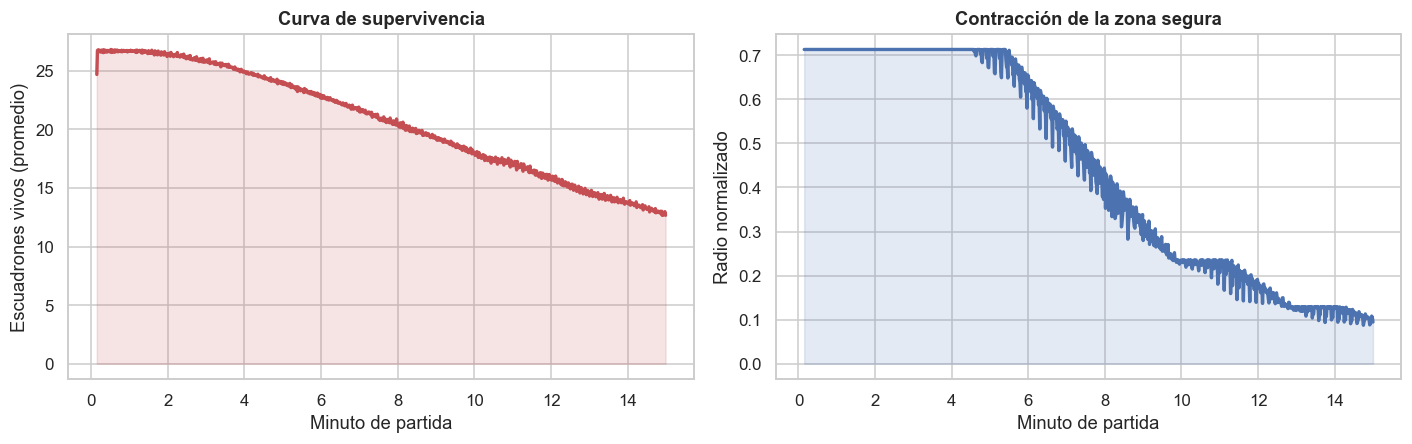

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Curva de supervivencia
sup = df.groupby("t").num_alive_teams.mean()
axes[0].plot(sup.index / 60, sup.values, lw=2.2, color="#c44e52")
axes[0].set(xlabel="Minuto de partida", ylabel="Escuadrones vivos (promedio)",
            title="Curva de supervivencia")
axes[0].fill_between(sup.index / 60, sup.values, alpha=.15, color="#c44e52")

# Contracción de la zona segura
rz = zona[zona.t <= T_MAX].groupby("t").safety_r_norm.mean()
axes[1].plot(rz.index / 60, rz.values, lw=2.2, color="#4c72b0")
axes[1].set(xlabel="Minuto de partida", ylabel="Radio normalizado",
            title="Contracción de la zona segura")
axes[1].fill_between(rz.index / 60, rz.values, alpha=.15, color="#4c72b0")

plt.tight_layout(); plt.show()

### 5.2 Distribución de las variables continuas

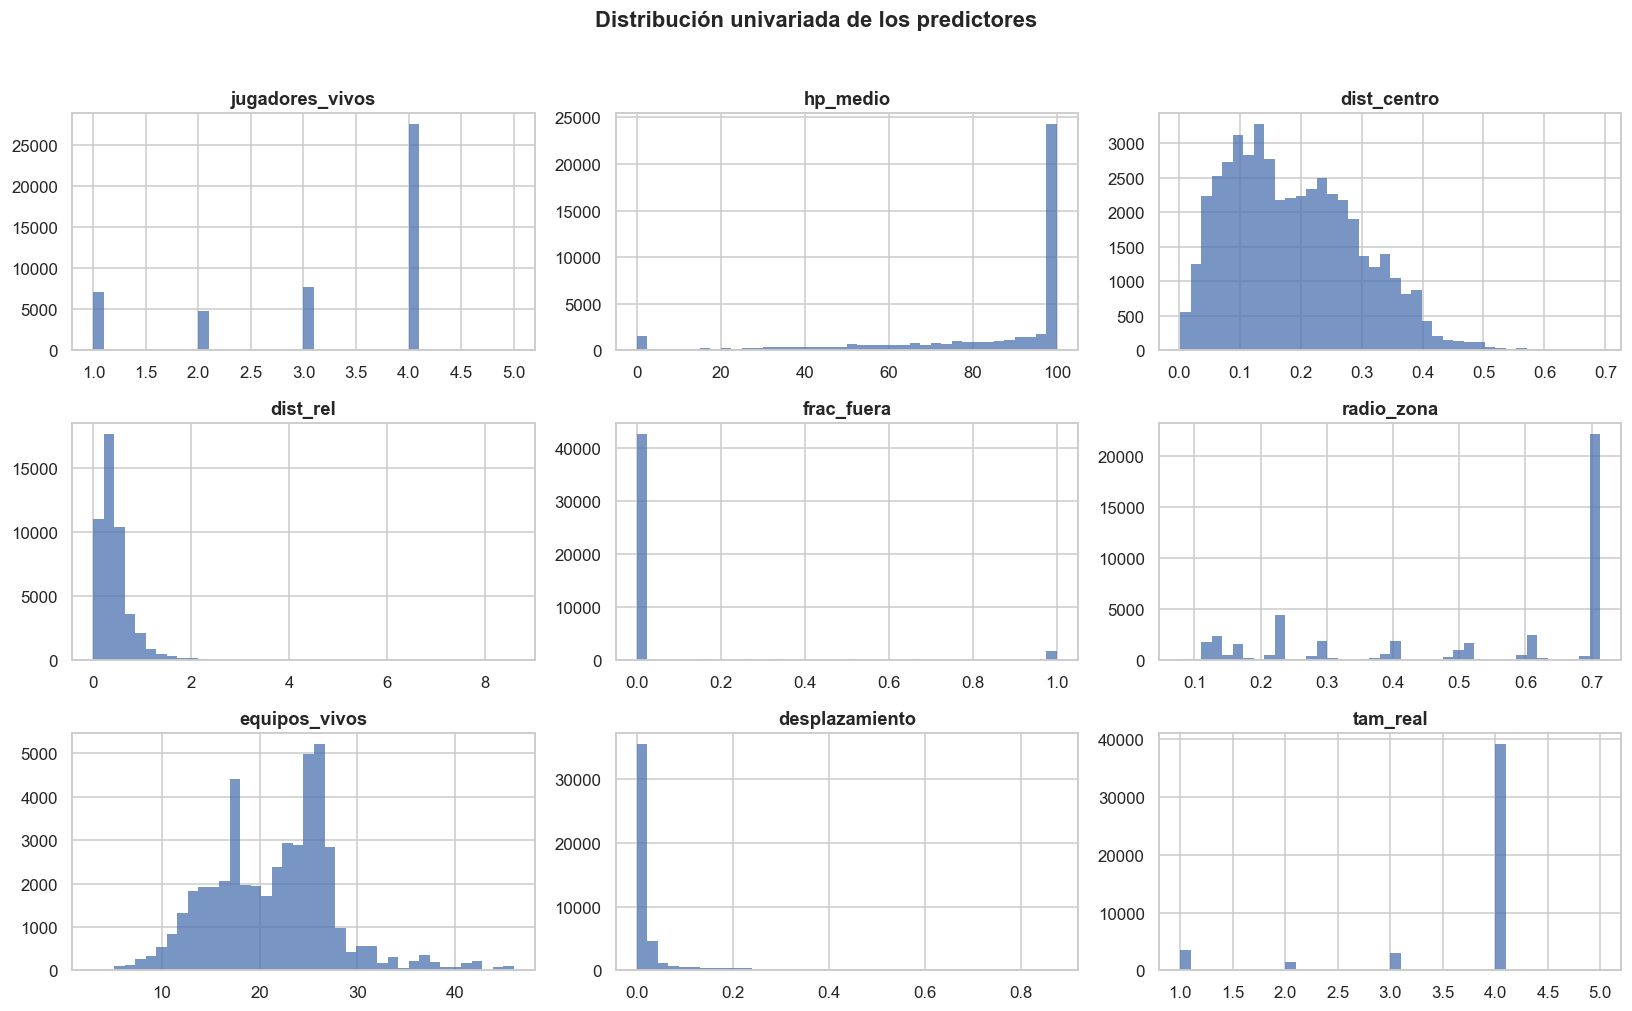

,count,mean,std,min,25%,50%,75%,max
jugadores_vivos,47218.0,3.181,1.121,1.000,2.000,4.000,4.000,5.000
hp_medio,47218.0,82.223,26.908,0.000,72.560,98.427,100.000,100.000
dist_centro,47152.0,0.189,0.107,0.003,0.103,0.176,0.264,0.692
dist_rel,47152.0,0.457,0.370,0.011,0.240,0.379,0.540,8.573
frac_fuera,47218.0,0.061,0.216,0.000,0.000,0.000,0.000,1.000
radio_zona,47152.0,0.508,0.230,0.078,0.235,0.616,0.713,0.713
equipos_vivos,47152.0,21.563,6.389,3.000,17.000,22.000,26.000,46.000
desplazamiento,47218.0,0.040,0.092,0.000,0.003,0.008,0.022,0.874
tam_real,47218.0,3.646,0.865,1.000,4.000,4.000,4.000,5.000


In [7]:
# Conjunto de predictores. fase_zona se excluye deliberadamente: es una
# discretización de radio_zona, de modo que incluir ambas sería redundante.
# Se emplea como eje del análisis, no como variable más.
num = ["jugadores_vivos", "hp_medio", "dist_centro", "dist_rel",
       "frac_fuera", "radio_zona", "equipos_vivos", "desplazamiento", "tam_real"]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, c in zip(axes.ravel(), num):
    sns.histplot(agg[c], bins=40, ax=ax, color="#4c72b0", edgecolor="none")
    ax.set(title=c, xlabel="", ylabel="")
plt.suptitle("Distribución univariada de los predictores", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

display(agg[num].describe().T.round(3))

### 5.3 Geografía de las bajas

La distribución espacial de las eliminaciones revela si el mapa tiene zonas de riesgo diferenciado, lo cual justificaría incorporar la posición absoluta como predictor y no solo la posición relativa al círculo.

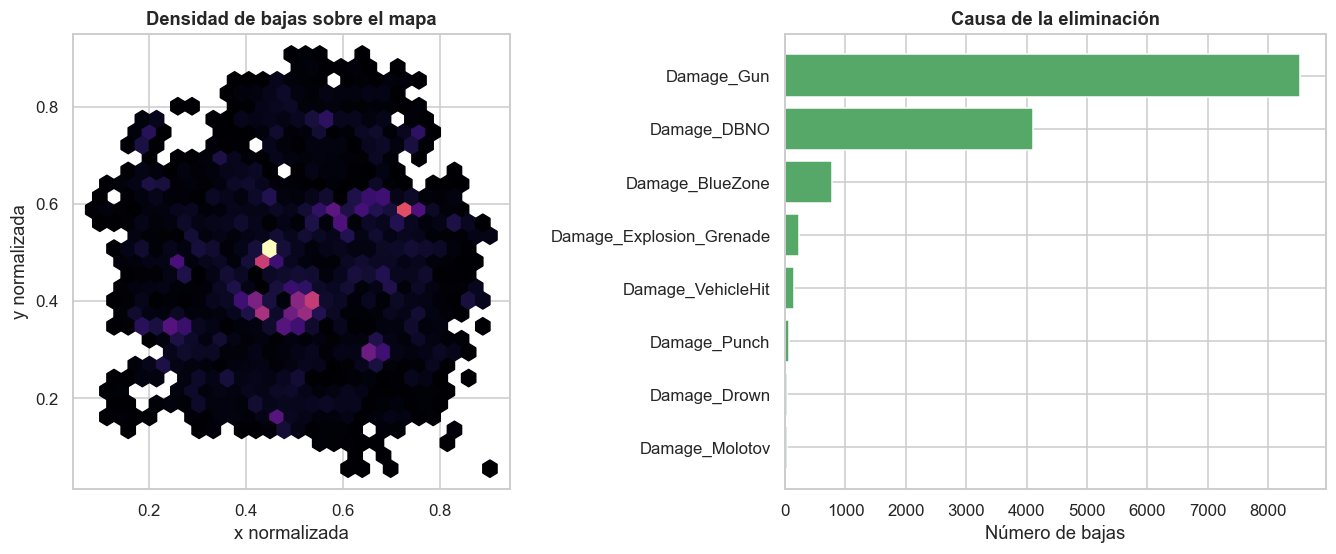

In [8]:
m = muertes.dropna(subset=["victim_x_norm", "victim_y_norm"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

axes[0].hexbin(m.victim_x_norm, m.victim_y_norm, gridsize=28,
               cmap="magma", mincnt=1)
axes[0].set(title="Densidad de bajas sobre el mapa",
            xlabel="x normalizada", ylabel="y normalizada")
axes[0].set_aspect("equal")

cat = muertes.damage_category.value_counts().head(8)
axes[1].barh(cat.index.astype(str), cat.values, color="#55a868")
axes[1].set(title="Causa de la eliminación", xlabel="Número de bajas")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

### 5.4 Relación entre conducta y desenlace

Esta sección determina si las variables construidas separan a los escuadrones
que llegan al cuarto superior de los que no. El eje es la **fase de la zona**,
no el minuto de reloj, por las razones expuestas en 3.3.

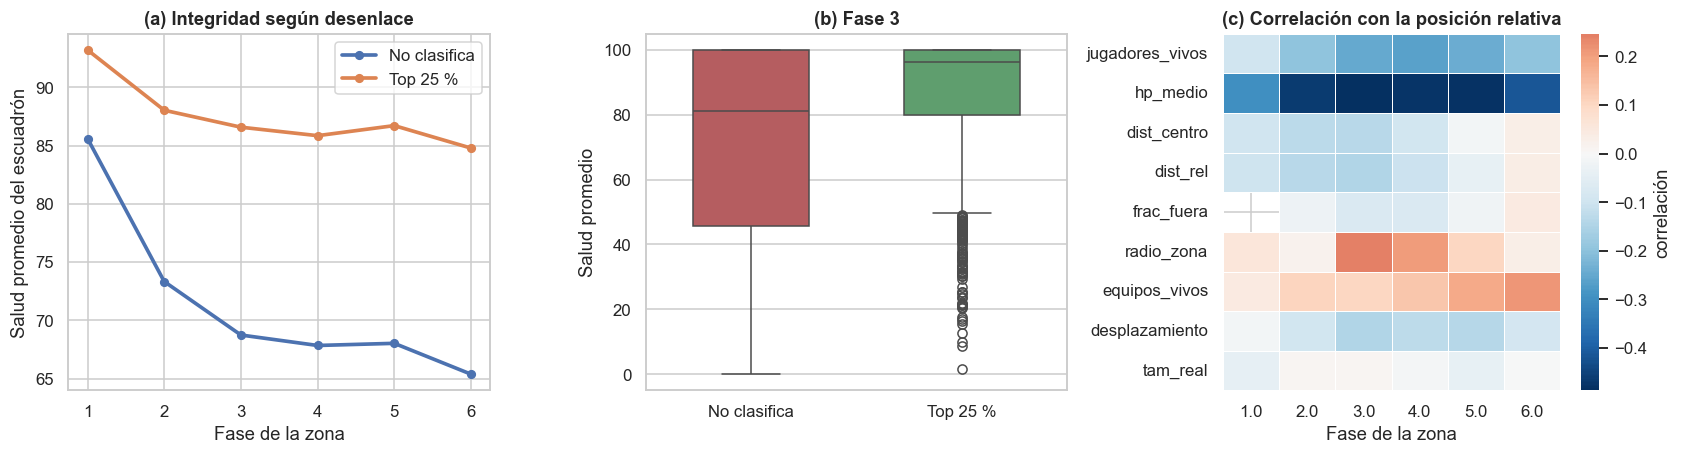

Salud promedio del escuadrón en la fase 3:
         mean     std  count
top25                       
0      68.740  34.002   2008
1      86.577  19.816   1041


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

# (a) Salud del escuadrón según desenlace, por fase de la zona
tray = agg.groupby(["fase_zona", "top25"]).hp_medio.mean().unstack()
tray.columns = ["No clasifica", "Top 25 %"]
tray.plot(ax=axes[0], lw=2.4, marker="o", ms=5)
axes[0].set(xlabel="Fase de la zona", ylabel="Salud promedio del escuadrón",
            title="(a) Integridad según desenlace")
axes[0].legend(title="")

# (b) Separación en una fase intermedia
f3 = agg[agg.fase_zona == 3]
sns.boxplot(data=f3, x="top25", y="hp_medio", ax=axes[1],
            palette=["#c44e52", "#55a868"], width=.55)
axes[1].set(xticklabels=["No clasifica", "Top 25 %"], xlabel="",
            ylabel="Salud promedio", title="(b) Fase 3")

# (c) Correlación de cada predictor con la posición final, por fase
cors = (agg.dropna(subset=["fase_zona"])
           .groupby("fase_zona")
           .apply(lambda g: g[num].corrwith(g.pct_rank)))
sns.heatmap(cors.T, cmap="RdBu_r", center=0, ax=axes[2],
            cbar_kws={"label": "correlación"}, linewidths=.4)
axes[2].set(xlabel="Fase de la zona", ylabel="",
            title="(c) Correlación con la posición relativa")

plt.tight_layout(); plt.show()

print("Salud promedio del escuadrón en la fase 3:")
print(f3.groupby("top25").hp_medio.agg(["mean", "std", "count"]).round(3))

### 5.5 Multicolinealidad

El temario exige evaluar la multicolinealidad antes de modelar. Se calcula el factor de inflación de varianza regresando cada predictor contra el resto: valores superiores a diez indican redundancia que compromete la interpretación de los coeficientes en modelos lineales.

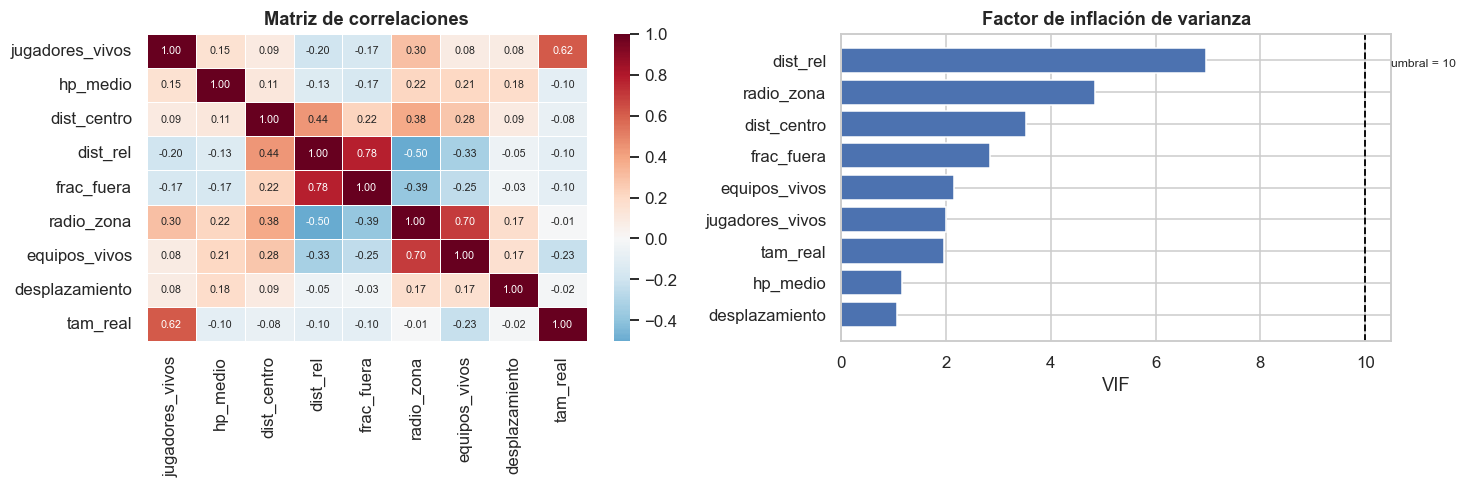

dist_rel           6.96
radio_zona         4.84
dist_centro        3.53
frac_fuera         2.85
equipos_vivos      2.15
jugadores_vivos    2.00
tam_real           1.95
hp_medio           1.16
desplazamiento     1.06


In [10]:
from sklearn.linear_model import LinearRegression

def vif(X: pd.DataFrame) -> pd.Series:
    """Factor de inflación de varianza: 1 / (1 - R²) de cada variable
    regresada contra todas las demás."""
    out = {}
    for c in X.columns:
        r2 = LinearRegression().fit(X.drop(columns=c), X[c]).score(
             X.drop(columns=c), X[c])
        out[c] = 1 / (1 - r2) if r2 < 0.9999 else np.inf
    return pd.Series(out).sort_values(ascending=False)

X = agg[num].dropna()
tabla_vif = vif(X)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

sns.heatmap(X.corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=axes[0], linewidths=.4)
axes[0].set_title("Matriz de correlaciones")

colores = ["#c44e52" if v > 10 else "#4c72b0" for v in tabla_vif.values]
axes[1].barh(tabla_vif.index, tabla_vif.values, color=colores)
axes[1].axvline(10, ls="--", c="black", lw=1.2)
axes[1].annotate("umbral = 10", (10.5, 0.2), fontsize=8)
axes[1].set(title="Factor de inflación de varianza", xlabel="VIF")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()
print(tabla_vif.round(2).to_string())

**Hallazgo.** Ningún predictor supera el umbral convencional de diez. El valor
más alto corresponde a `dist_rel`, lo que era previsible: se construye a partir
de `dist_centro` y `radio_zona`, ambas presentes en el conjunto.

Este resultado tiene una consecuencia práctica favorable. No es necesario
descartar variables por redundancia, de modo que los modelos lineales pueden
utilizar el conjunto completo sin comprometer la interpretación de sus
coeficientes. La única correlación notable, entre `radio_zona` y
`equipos_vivos`, refleja que ambas son función del avance de la partida, pero se
mantiene en un nivel que no impide el ajuste.

### 5.6 Reducción de dimensionalidad

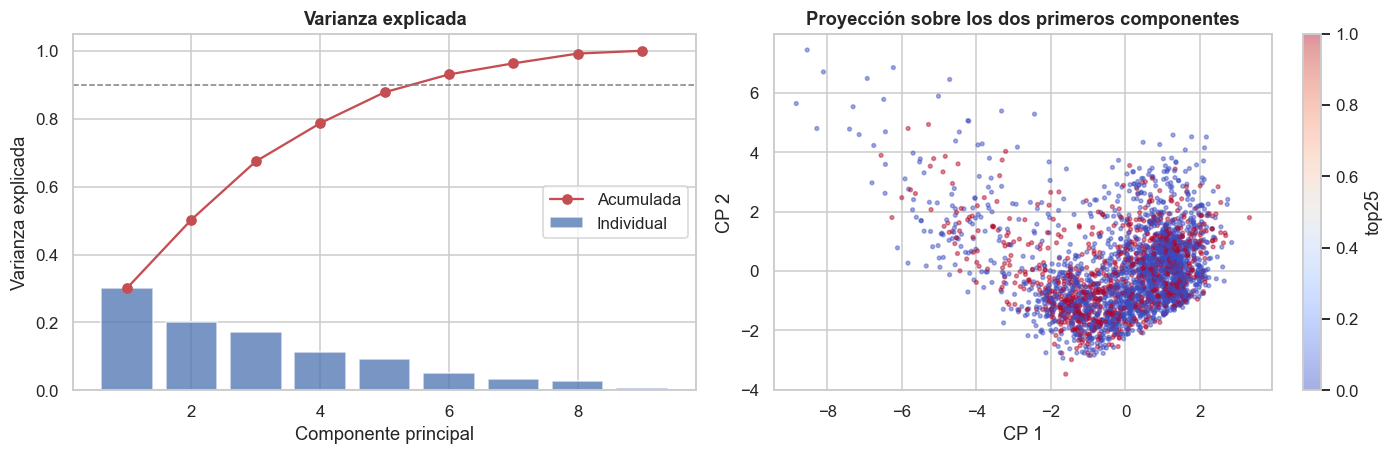

Componentes necesarios para explicar el 90% de la varianza: 6 de 9
Varianza acumulada: [0.301 0.503 0.674 0.787 0.878 0.93  0.963 0.992 1.   ]

Cargas de los tres primeros componentes:


,CP1,CP2,CP3
jugadores_vivos,0.259,-0.216,0.608
hp_medio,0.233,0.183,0.029
dist_centro,0.035,0.562,0.372
dist_rel,-0.476,0.333,0.276
frac_fuera,-0.441,0.286,0.232
radio_zona,0.506,0.252,0.082
equipos_vivos,0.416,0.365,-0.095
desplazamiento,0.152,0.185,0.099
tam_real,0.068,-0.425,0.579


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Z    = StandardScaler().fit_transform(X)
pca  = PCA().fit(Z)
acum = np.cumsum(pca.explained_variance_ratio_)
k90  = int(np.argmax(acum >= .90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].bar(range(1, len(acum) + 1), pca.explained_variance_ratio_,
            color="#4c72b0", alpha=.75, label="Individual")
axes[0].plot(range(1, len(acum) + 1), acum, "o-", color="#c44e52",
             label="Acumulada")
axes[0].axhline(.90, ls="--", c="gray", lw=1)
axes[0].set(xlabel="Componente principal", ylabel="Varianza explicada",
            title="Varianza explicada")
axes[0].legend()

Y = pca.transform(Z)[:, :2]
idx = np.random.choice(len(Y), min(3000, len(Y)), replace=False)
sc = axes[1].scatter(Y[idx, 0], Y[idx, 1], c=X.index.map(agg.top25)[idx],
                     cmap="coolwarm", s=6, alpha=.45)
axes[1].set(xlabel="CP 1", ylabel="CP 2",
            title="Proyección sobre los dos primeros componentes")
plt.colorbar(sc, ax=axes[1], label="top25")

plt.tight_layout(); plt.show()

print(f"Componentes necesarios para explicar el 90% de la varianza: {k90} de {len(num)}")
print("Varianza acumulada:", np.round(acum, 3))

cargas = pd.DataFrame(pca.components_[:3].T, index=num,
                      columns=["CP1", "CP2", "CP3"]).round(3)
print("\nCargas de los tres primeros componentes:")
display(cargas)

### 5.7 Poder predictivo individual

Antes de ajustar cualquier modelo conviene medir cuánta información aporta cada variable por separado. Se usa la información mutua, que a diferencia de la correlación detecta relaciones no lineales.

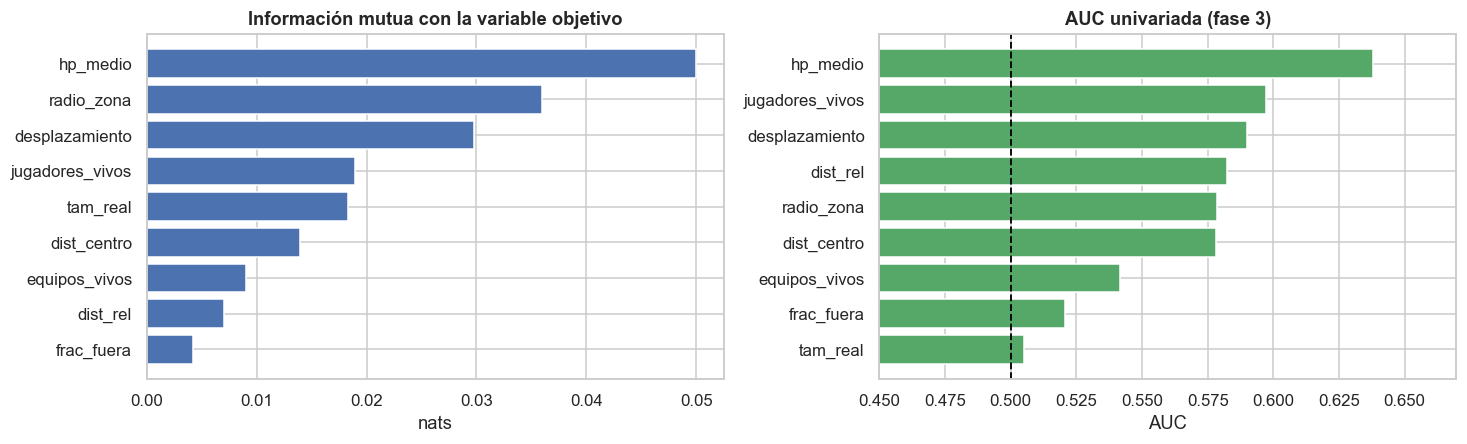

hp_medio           0.638
jugadores_vivos    0.597
desplazamiento     0.590
dist_rel           0.582
radio_zona         0.578
dist_centro        0.578
equipos_vivos      0.542
frac_fuera         0.521
tam_real           0.505


In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

# Se evalúa en una fase intermedia, no en un minuto de reloj
v = agg[agg.fase_zona == 3].dropna(subset=num)
mi = pd.Series(mutual_info_classif(v[num], v.top25, random_state=SEMILLA),
               index=num).sort_values()

# AUC univariada: qué tan bien separa cada variable por sí sola
auc = {}
for c in num:
    a = roc_auc_score(v.top25, v[c])
    auc[c] = max(a, 1 - a)          # se ignora el sentido de la relación
auc = pd.Series(auc).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].barh(mi.index, mi.values, color="#4c72b0")
axes[0].set(title="Información mutua con la variable objetivo", xlabel="nats")
axes[1].barh(auc.index, auc.values, color="#55a868")
axes[1].axvline(.5, ls="--", c="black", lw=1.2)
axes[1].set(title="AUC univariada (fase 3)", xlabel="AUC", xlim=(.45, None))
plt.tight_layout(); plt.show()

print(auc.sort_values(ascending=False).round(3).to_string())

### 5.8 Separabilidad a lo largo de la partida

El indicador central del proyecto es la cantidad de información sobre el
desenlace disponible en cada momento. Se mide como el área bajo la curva que
alcanza el mejor predictor individual, evaluado fase por fase.

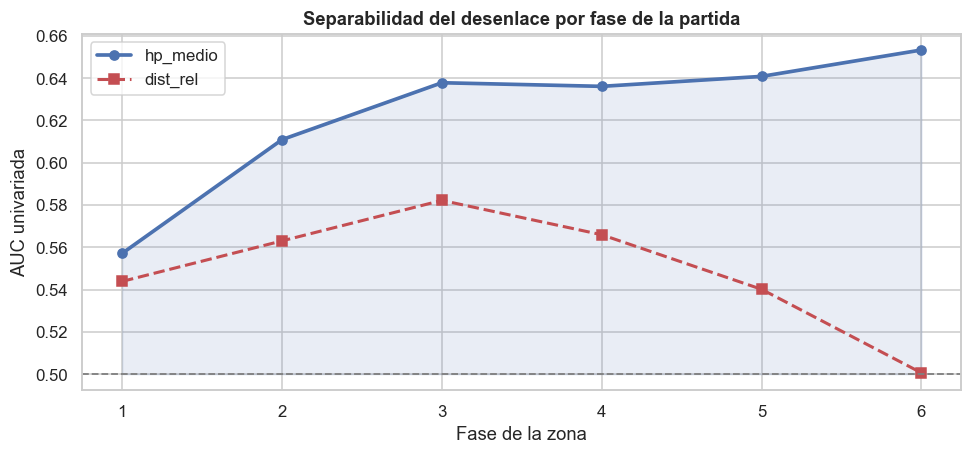

Mejor predictor (hp_medio):


,fase_zona,auc,n,tasa_base
0,1.0,0.557,25491,0.278
1,2.0,0.611,3751,0.331
2,3.0,0.638,3049,0.341
3,4.0,0.636,2857,0.365
4,5.0,0.641,7308,0.414
5,6.0,0.653,4696,0.495


In [13]:
from sklearn.metrics import roc_auc_score

def auc_por(eje, var):
    """AUC univariada de `var` sobre top25, calculada dentro de cada nivel de `eje`."""
    filas = []
    for k, g in agg.groupby(eje):
        g = g.dropna(subset=[var])
        if g.top25.nunique() < 2 or len(g) < 200:
            continue
        a = roc_auc_score(g.top25, g[var])
        filas.append({eje: k, "auc": max(a, 1 - a), "n": len(g),
                      "tasa_base": round(g.top25.mean(), 3)})
    return pd.DataFrame(filas)

sep_hp   = auc_por("fase_zona", "hp_medio")
sep_dist = auc_por("fase_zona", "dist_rel")

plt.figure(figsize=(9, 4.3))
plt.plot(sep_hp.fase_zona,   sep_hp.auc,   "o-", lw=2.4,
         color="#4c72b0", label="hp_medio")
plt.plot(sep_dist.fase_zona, sep_dist.auc, "s--", lw=2.0,
         color="#c44e52", label="dist_rel")
plt.axhline(.5, ls="--", c="gray", lw=1.2)
plt.fill_between(sep_hp.fase_zona, .5, sep_hp.auc, alpha=.12, color="#4c72b0")
plt.xlabel("Fase de la zona"); plt.ylabel("AUC univariada")
plt.title("Separabilidad del desenlace por fase de la partida")
plt.legend(); plt.tight_layout(); plt.show()

print("Mejor predictor (hp_medio):"); display(sep_hp.round(3))

### 5.9 Refutación de la hipótesis inicial

El diseño del proyecto partió de una hipótesis explícita: que el posicionamiento
relativo a la zona segura, recogido en `dist_rel`, sería el principal
determinante del desenlace. La intuición era razonable —quedar fuera del círculo
ocasiona daño continuo— y motivó la construcción de esa variable como pieza
central de la ingeniería de características.

El análisis exploratorio no la sostiene. Esta sección documenta la refutación y
el replanteamiento que se derivó de ella.

In [14]:
# --- (1) dist_rel confunde posicionamiento con avance de la partida ----------
diag = agg.groupby("fase_zona").agg(n=("team_id", "size"),
                                    tasa_top25=("top25", "mean"),
                                    dist_rel=("dist_rel", "mean")).round(3)
print("Comportamiento de dist_rel a lo largo de las fases:")
display(diag)

# --- (2) ¿Recupera poder predictivo al controlar por fase? -------------------
print("\nAUC de dist_rel DENTRO de cada fase (comparación justa):")
display(sep_dist.round(3))

# --- (3) La fase por sí sola, como referencia -------------------------------
gf = agg.dropna(subset=["fase_zona"])
a  = roc_auc_score(gf.top25, gf.fase_zona)
print(f"\nAUC de fase_zona por sí sola: {max(a, 1-a):.3f}")
print("(Refleja sobre todo el sesgo de supervivencia, no capacidad predictiva)")

# --- (4) Qué mata realmente en el juego --------------------------------------
causas = muertes.damage_category.value_counts(normalize=True).head(5).round(4)
print("\nCausa de las eliminaciones (proporción):")
display(causas)

Comportamiento de dist_rel a lo largo de las fases:


,n,tasa_top25,dist_rel
fase_zona,,,
1.0,25491,0.278,0.318
2.0,3751,0.331,0.355
3.0,3049,0.341,0.423
4.0,2857,0.365,0.587
5.0,7308,0.414,0.707
6.0,4696,0.495,0.847



AUC de dist_rel DENTRO de cada fase (comparación justa):


,fase_zona,auc,n,tasa_base
0,1.0,0.544,25491,0.278
1,2.0,0.563,3751,0.331
2,3.0,0.582,3049,0.341
3,4.0,0.566,2857,0.365
4,5.0,0.540,7308,0.414
5,6.0,0.501,4696,0.495



AUC de fase_zona por sí sola: 0.584
(Refleja sobre todo el sesgo de supervivencia, no capacidad predictiva)

Causa de las eliminaciones (proporción):


damage_category
Damage_Gun                  0.6078
Damage_DBNO                 0.2928
Damage_BlueZone             0.0549
Damage_Explosion_Grenade    0.0158
Damage_VehicleHit           0.0100
Name: proportion, dtype: float64

**Diagnóstico.** La distancia relativa crece de forma sostenida conforme el
círculo se contrae, lo que era esperable: a menor radio, mayor distancia
relativa para una misma separación absoluta. Como las fases avanzadas solo las
alcanzan los escuadrones que sobrevivieron, la variable termina midiendo, en
buena parte, cuán lejos llegó el equipo y no cuán bien se posicionó. Es un caso
de confusión estadística de manual, y explica que la asociación aparente aparezca
incluso con el signo invertido.

Al controlar por fase, que es la comparación justa, `dist_rel` mejora pero no lo
bastante para sostener un planteamiento.

**Por qué falla la intuición.** La distribución de causas de eliminación lo
aclara: la zona de gas produce una fracción pequeña de las bajas, mientras que
la abrumadora mayoría procede de armas de fuego. En una partida de esta duración
no mata el círculo, matan los adversarios. El posicionamiento importa como
mediador —determina con quién te encuentras— pero no como causa directa.

**Replanteamiento.** Los predictores efectivos resultan ser los que describen la
condición del escuadrón: salud promedio, integrantes con vida y movilidad. El
proyecto se reformula en consecuencia:

> Estimación del estado competitivo de un escuadrón a partir de su **integridad
> y condición**, condicionada a la fase de la partida.

`dist_rel` se conserva en el conjunto de predictores por dos motivos. Primero,
porque su interacción con la salud puede resultar informativa aunque su efecto
aislado no lo sea: un escuadrón herido y fuera de la zona no se encuentra en la
misma situación que uno herido y protegido, y los modelos de ensamble y las
redes neuronales pueden capturar esa interacción. Segundo, porque documentar una
variable que la teoría sugería y los datos desmienten forma parte del
resultado.

## 6. Conclusiones de la etapa exploratoria

**Sobre los datos.** La interfaz oficial entrega información suficiente y de
buena calidad. Las 150 partidas presentan etiquetas íntegras: todas tienen
exactamente un escuadrón ganador y las posiciones finales forman secuencias
completas. Los valores ausentes son marginales y de origen estructural, salvo
`desplazamiento`, cuya ausencia en la primera ventana de cada escuadrón responde
a su propia definición y admite imputación justificada.

**Sobre la señal.** La integridad del escuadrón —salud promedio, integrantes con
vida— discrimina el desenlace con claridad, mientras que el posicionamiento
relativo a la zona no lo hace. Esta conclusión contradice la hipótesis con la que
se diseñó la ingeniería de características, y su documentación se presenta en la
sección 5.9.

**Sobre la estructura temporal.** El minuto de reloj no es comparable entre
partidas, porque cada una entra en las fases del círculo en momentos distintos.
El eje temporal correcto es la fase de la zona, y todo el análisis se organiza
sobre ella.

**Sobre el sesgo de supervivencia.** La tasa de escuadrones destinados al cuarto
superior crece de forma monótona entre los supervivientes, hasta más que
duplicarse hacia el final del horizonte analizado. Es una propiedad del
fenómeno, no un defecto del muestreo, y reformula la pregunta del sistema en
términos condicionales.

**Sobre la estructura de dependencia.** Ningún predictor presenta
multicolinealidad problemática. No es necesario descartar variables y los
modelos lineales pueden emplear el conjunto completo.

### Implicaciones para la siguiente etapa

1. Emplear `top25` como variable objetivo, nunca la posición absoluta.
2. Construir las secuencias sobre la fase de la zona, no sobre el minuto.
3. Ponderar las clases durante el entrenamiento y evaluar con área bajo la curva
   y puntaje de Brier.
4. Particionar por fecha de partida, nunca de forma aleatoria: las ventanas de
   una misma partida están correlacionadas entre sí.
5. Evaluar el desempeño **dentro de cada fase**, para que la tasa base creciente
   no se confunda con capacidad predictiva del modelo.

In [15]:
# Persistencia de la tabla analítica para la siguiente etapa.
# Se intenta Parquet por eficiencia y preservación de tipos; si el entorno no
# cuenta con un motor disponible se recurre a CSV comprimido, de modo que el
# notebook nunca interrumpe su ejecución por una dependencia opcional.
try:
    destino = BASE / "tabla_analitica.parquet"
    agg.to_parquet(destino, index=False)
except ImportError:
    destino = BASE / "tabla_analitica.csv.gz"
    agg.to_csv(destino, index=False, compression="gzip")

print(f"Guardado: {destino} — {agg.shape[0]:,} filas × {agg.shape[1]} columnas")

Guardado: datos\tabla_analitica.csv.gz — 47,218 filas × 20 columnas


## Referencias

Krafton. (2026). *PUBG Developer Portal — API documentation*. https://documentation.pubg.com/

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55